# Exploration — Bioclimatic Monthly Time Series (2000-2019)

Fichiers concernés :
- `data/BioclimTimeSeries/values/GLC25-PA-train-bioclimatic_monthly.csv`
- `data/BioclimTimeSeries/values/GLC25-PA-test-bioclimatic_monthly.csv`

Source : CHELSA, résolution ~1km. 4 variables climatiques mensuelles × 12 mois × 20 ans = **960 colonnes** :
- `Bio-pr_MM_YYYY` : précipitations (pr)
- `Bio-tas_MM_YYYY` : température moyenne (tas)
- `Bio-tasmax_MM_YYYY` : température maximale (tasmax)
- `Bio-tasmin_MM_YYYY` : température minimale (tasmin)

Période : janvier 2000 – décembre 2019.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BIO_DIR = '../data/BioclimTimeSeries/values/'

print('Chargement du train...')
train = pd.read_csv(BIO_DIR + 'GLC25-PA-train-bioclimatic_monthly.csv', index_col='surveyId')
print('Chargement du test...')
test  = pd.read_csv(BIO_DIR + 'GLC25-PA-test-bioclimatic_monthly.csv', index_col='surveyId')

print('Train shape:', train.shape)
print('Test  shape:', test.shape)

Chargement du train...
Chargement du test...
Train shape: (88987, 912)
Test  shape: (14829, 912)


## 1. Organisation des colonnes

In [2]:
cols = train.columns.tolist()
print(f'Total colonnes : {len(cols)}')
print('Premières colonnes:', cols[:8])
print('Dernières colonnes:', cols[-8:])

# Identifier les 4 variables
var_types = set(c.split('_')[0].replace('Bio-', '') for c in cols)
print('\nTypes de variables:', var_types)

Total colonnes : 912
Premières colonnes: ['Bio-pr_01_2000', 'Bio-tas_01_2000', 'Bio-tasmax_01_2000', 'Bio-tasmin_01_2000', 'Bio-pr_02_2000', 'Bio-tas_02_2000', 'Bio-tasmax_02_2000', 'Bio-tasmin_02_2000']
Dernières colonnes: ['Bio-pr_11_2018', 'Bio-tas_11_2018', 'Bio-tasmax_11_2018', 'Bio-tasmin_11_2018', 'Bio-pr_12_2018', 'Bio-tas_12_2018', 'Bio-tasmax_12_2018', 'Bio-tasmin_12_2018']

Types de variables: {'tas', 'tasmin', 'pr', 'tasmax'}


In [3]:
# Séparer par type de variable
pr_cols     = [c for c in cols if c.startswith('Bio-pr_')]
tas_cols    = [c for c in cols if c.startswith('Bio-tas_')]
tasmax_cols = [c for c in cols if c.startswith('Bio-tasmax_')]
tasmin_cols = [c for c in cols if c.startswith('Bio-tasmin_')]

print(f'pr: {len(pr_cols)}, tas: {len(tas_cols)}, tasmax: {len(tasmax_cols)}, tasmin: {len(tasmin_cols)}')

pr: 228, tas: 228, tasmax: 228, tasmin: 228


## 2. Valeurs manquantes

In [4]:
for var, var_cols in [('pr', pr_cols), ('tas', tas_cols), ('tasmax', tasmax_cols), ('tasmin', tasmin_cols)]:
    missing = train[var_cols].isnull().mean().mean()
    print(f'  Train {var:8s}: {missing*100:.2f}% NaN')

print()
for var, var_cols in [('pr', pr_cols), ('tas', tas_cols), ('tasmax', tasmax_cols), ('tasmin', tasmin_cols)]:
    missing = test[var_cols].isnull().mean().mean()
    print(f'  Test  {var:8s}: {missing*100:.2f}% NaN')

  Train pr      : 0.00% NaN
  Train tas     : 0.00% NaN
  Train tasmax  : 0.00% NaN
  Train tasmin  : 0.00% NaN

  Test  pr      : 0.00% NaN
  Test  tas     : 0.00% NaN
  Test  tasmax  : 0.00% NaN
  Test  tasmin  : 0.00% NaN


## 3. Profil temporel mensuel moyen

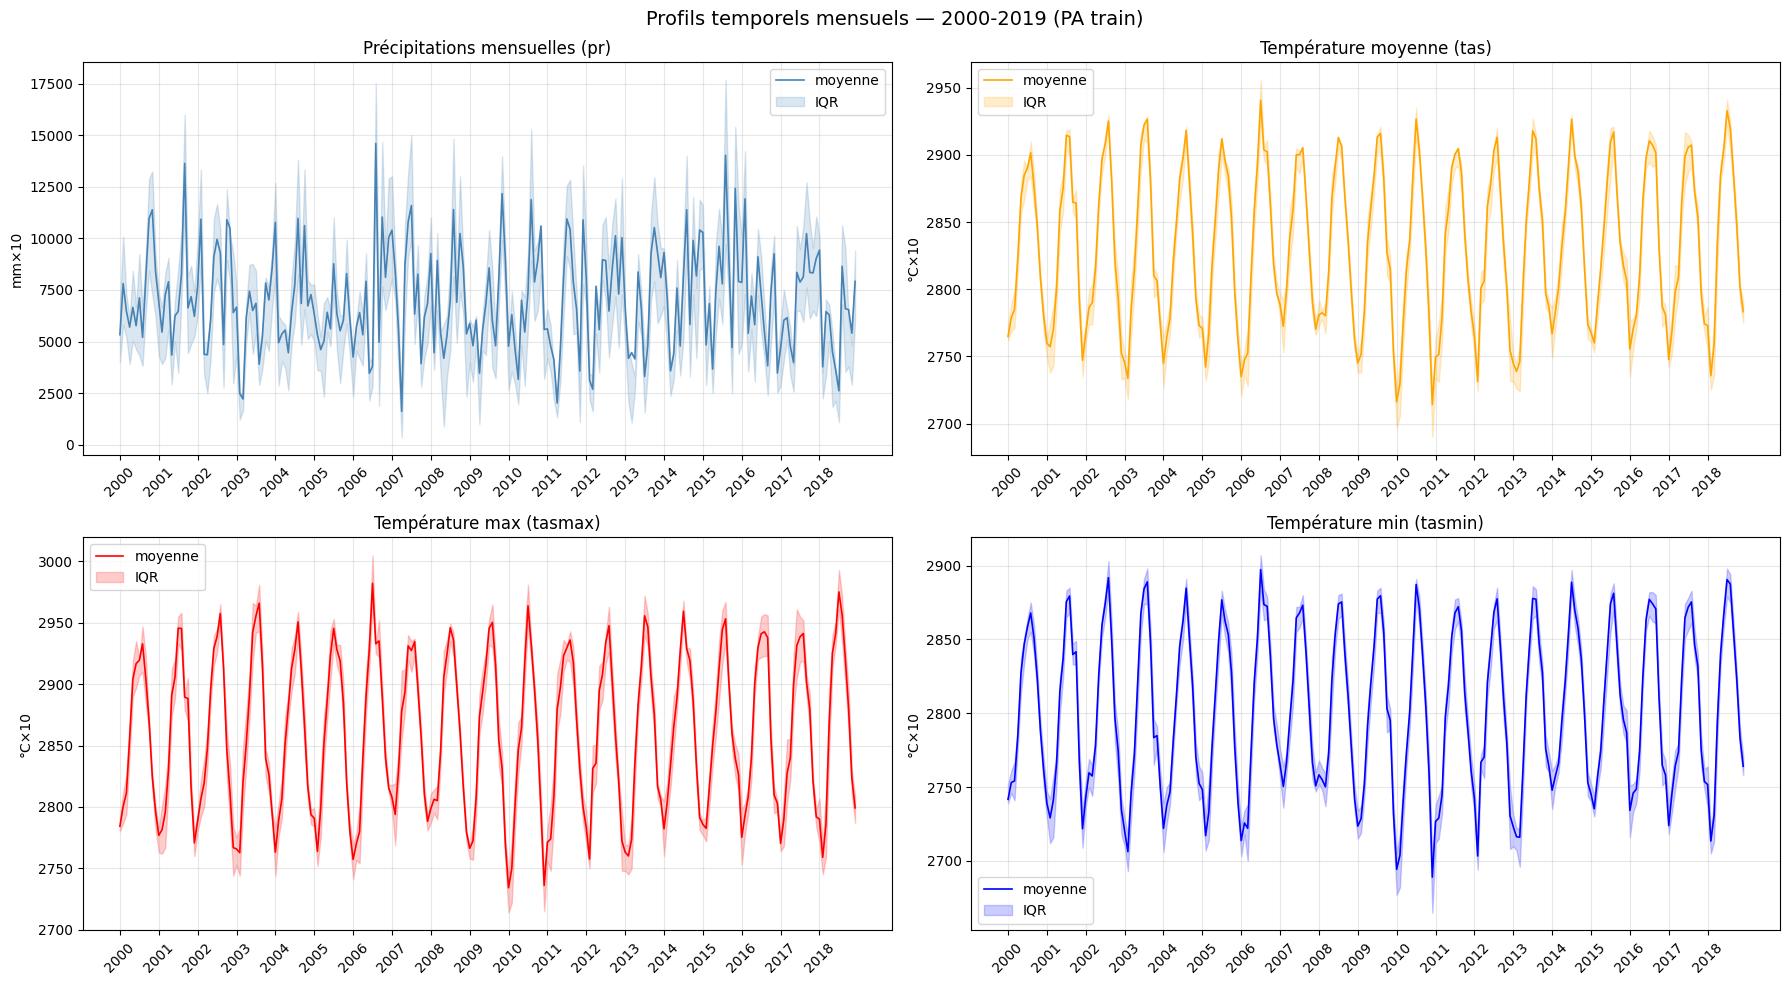

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

var_info = [
    ('pr',     pr_cols,     'steelblue', 'Précipitations mensuelles (pr)', 'mm×10'),
    ('tas',    tas_cols,    'orange',    'Température moyenne (tas)',      '°C×10'),
    ('tasmax', tasmax_cols, 'red',       'Température max (tasmax)',       '°C×10'),
    ('tasmin', tasmin_cols, 'blue',      'Température min (tasmin)',       '°C×10'),
]

for ax, (var, var_cols, color, title, unit) in zip(axes.flatten(), var_info):
    mean_ts = train[var_cols].mean(axis=0).values
    q25     = train[var_cols].quantile(0.25).values
    q75     = train[var_cols].quantile(0.75).values
    
    ax.plot(mean_ts, color=color, linewidth=1.2, label='moyenne')
    ax.fill_between(range(len(mean_ts)), q25, q75, alpha=0.2, color=color, label='IQR')
    
    # Ticks annuels
    year_ticks  = list(range(0, len(mean_ts), 12))
    year_labels = [var_cols[i].split('_')[2] for i in year_ticks]
    ax.set_xticks(year_ticks)
    ax.set_xticklabels(year_labels, rotation=45)
    ax.set_title(title)
    ax.set_ylabel(unit)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Profils temporels mensuels — 2000-2019 (PA train)', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Saisonnalité moyenne (profil mensuel agrégé sur toutes les années)

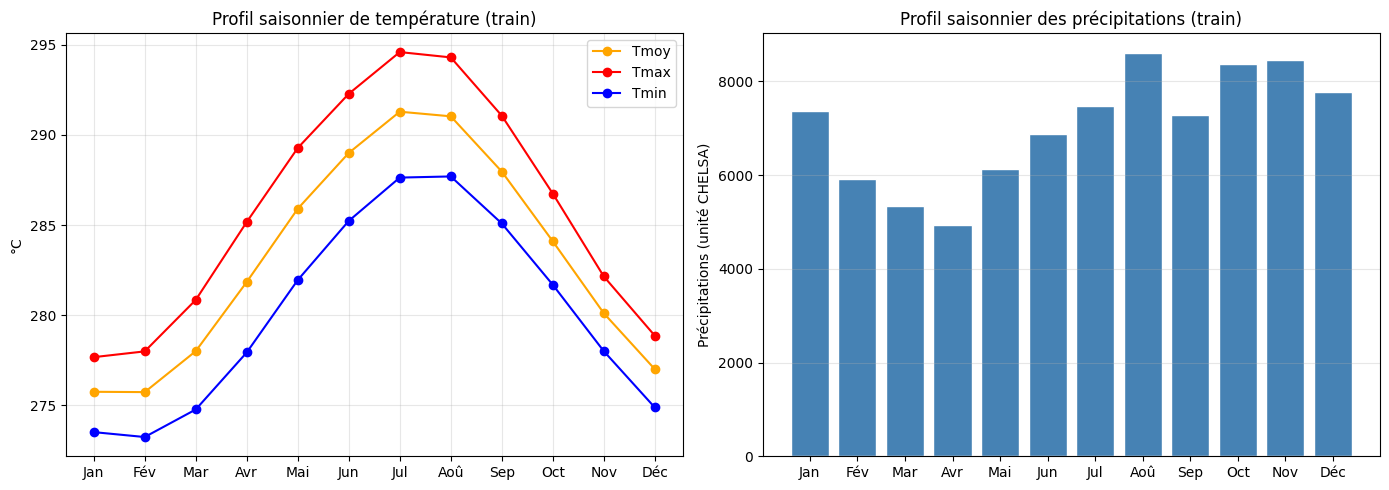

In [6]:
months = list(range(1, 13))
month_labels = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Température
ax = axes[0]
for var, var_cols, color, label in [
    ('tas',    tas_cols,    'orange', 'Tmoy'),
    ('tasmax', tasmax_cols, 'red',    'Tmax'),
    ('tasmin', tasmin_cols, 'blue',   'Tmin'),
]:
    monthly_mean = []
    for m in months:
        m_cols = [c for c in var_cols if f'_{m:02d}_' in c]
        monthly_mean.append(train[m_cols].values.mean() / 10)  # °C
    ax.plot(month_labels, monthly_mean, marker='o', color=color, label=label)
ax.set_title('Profil saisonnier de température (train)')
ax.set_ylabel('°C')
ax.legend()
ax.grid(alpha=0.3)

# Précipitations
ax = axes[1]
monthly_pr = []
for m in months:
    m_cols = [c for c in pr_cols if f'_{m:02d}_' in c]
    monthly_pr.append(train[m_cols].values.mean())
ax.bar(month_labels, monthly_pr, color='steelblue', edgecolor='white')
ax.set_title('Profil saisonnier des précipitations (train)')
ax.set_ylabel('Précipitations (unité CHELSA)')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 5. Exemple de série temporelle pour quelques surveys

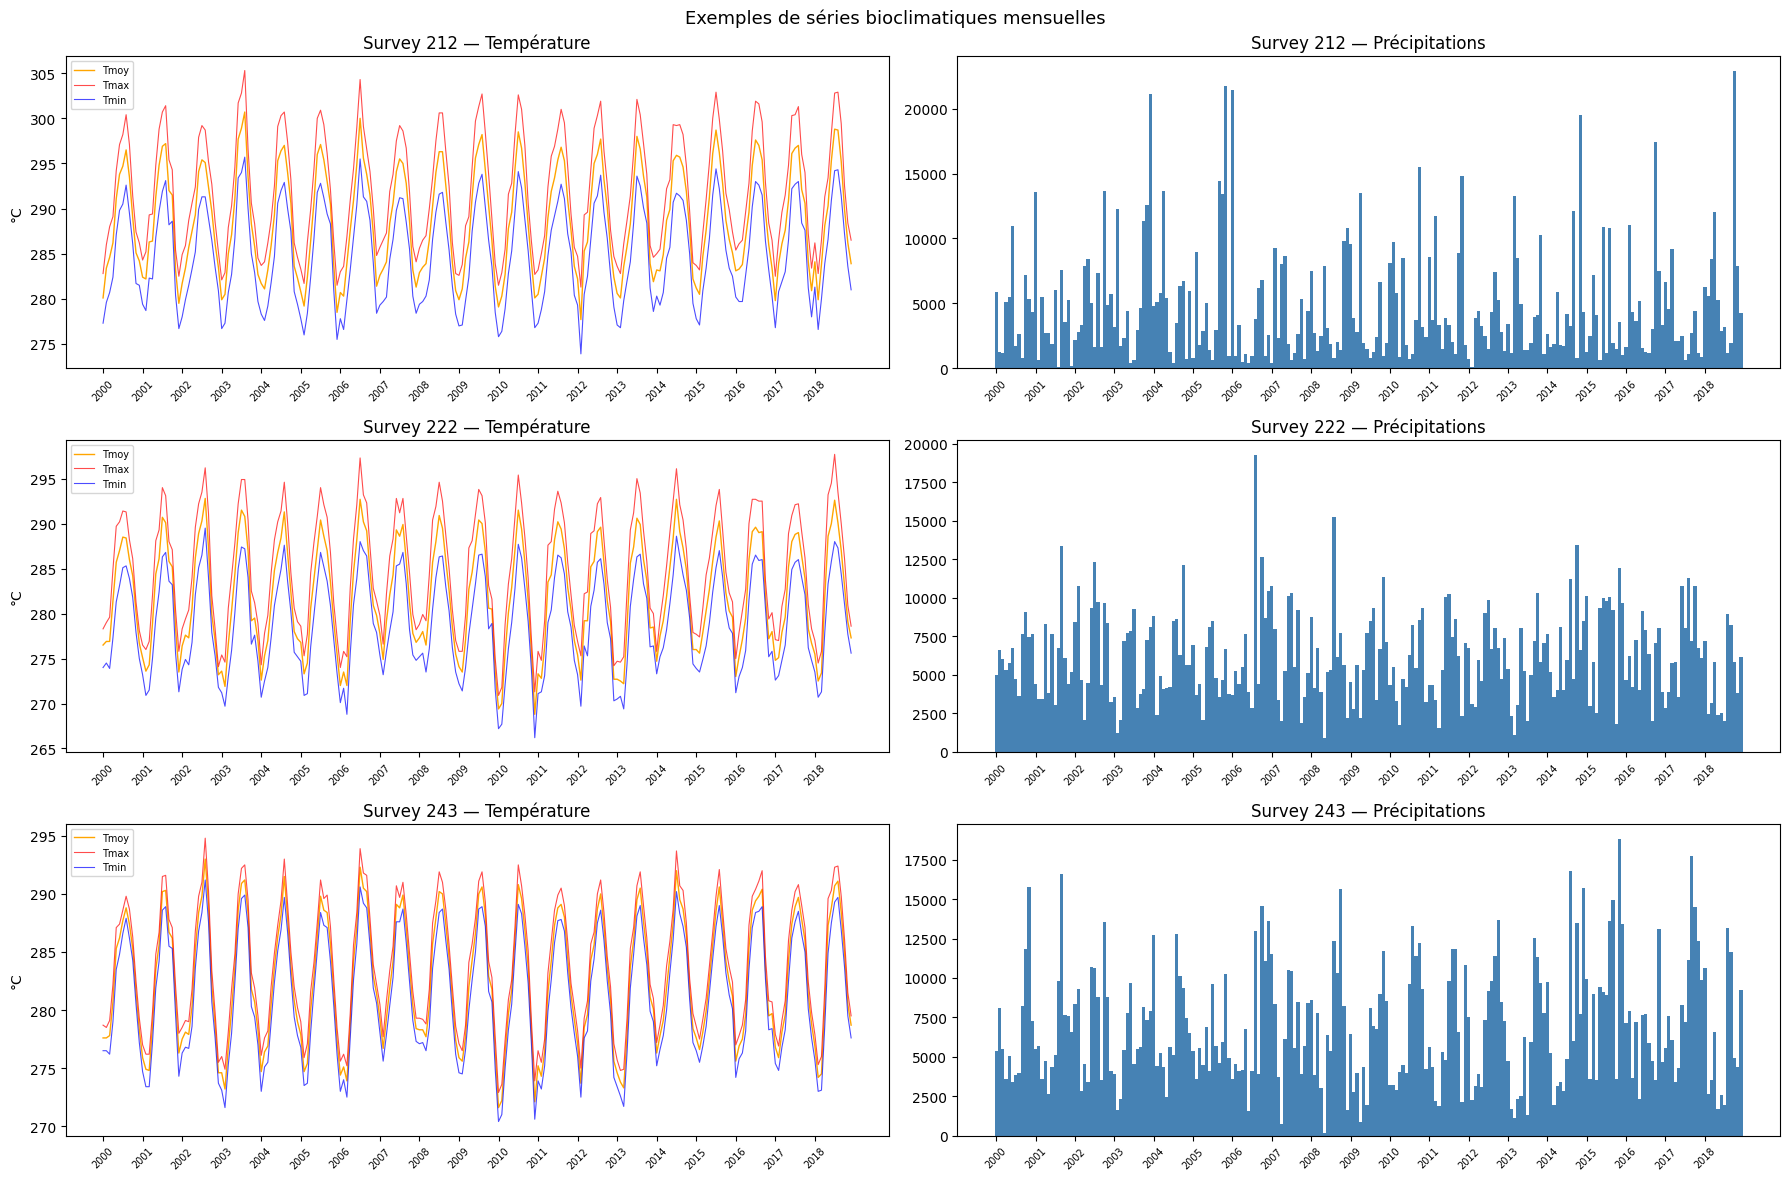

In [7]:
sample_ids = train.index[:3].tolist()

fig, axes = plt.subplots(len(sample_ids), 2, figsize=(18, 4*len(sample_ids)))

for i, sid in enumerate(sample_ids):
    # Température
    ax = axes[i, 0]
    ax.plot(train.loc[sid, tas_cols].values / 10, color='orange', label='Tmoy', linewidth=1)
    ax.plot(train.loc[sid, tasmax_cols].values / 10, color='red', label='Tmax', linewidth=0.8, alpha=0.7)
    ax.plot(train.loc[sid, tasmin_cols].values / 10, color='blue', label='Tmin', linewidth=0.8, alpha=0.7)
    ax.set_title(f'Survey {sid} — Température')
    ax.set_ylabel('°C')
    ax.legend(fontsize=7)
    year_ticks = list(range(0, len(tas_cols), 12))
    ax.set_xticks(year_ticks)
    ax.set_xticklabels([tas_cols[j].split('_')[2] for j in year_ticks], rotation=45, fontsize=7)
    
    # Précipitations
    ax = axes[i, 1]
    ax.bar(range(len(pr_cols)), train.loc[sid, pr_cols].values, color='steelblue', width=1)
    ax.set_title(f'Survey {sid} — Précipitations')
    ax.set_xticks(year_ticks)
    ax.set_xticklabels([pr_cols[j].split('_')[2] for j in year_ticks], rotation=45, fontsize=7)

plt.suptitle('Exemples de séries bioclimatiques mensuelles', fontsize=13)
plt.tight_layout()
plt.show()